## Анализ вероятности ухода клиента из банка

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import optuna
import warnings
import logging

from itertools import product
from tqdm.auto import tqdm
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from model_hub import modelsHub
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier, plot_importance


warnings.filterwarnings("ignore", message="X does not have valid feature names*")
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("optuna").setLevel(logging.WARNING)
RANDOM_STATE = 42
PRE_TRAINDED_MODE = True # использование лучших моделей из saved models

In [89]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

- **id** — уникальный идентификатор клиента 
- **gender** — пол клиента (Male, Female)  
- **SeniorCitizen** — признак пожилого клиента (1 — да, 0 — нет)  
- **Partner** — наличие партнёра (Yes, No)  
- **Dependents** — наличие иждивенцев (Yes, No)  
- **tenure** — длительность пользования услугами (в месяцах)  
- **PhoneService** — наличие телефонной связи (Yes, No)  
- **MultipleLines** — наличие нескольких телефонных линий (Yes, No, No phone service)  
- **InternetService** — тип интернет-подключения (DSL, Fiber optic, No)  
- **OnlineSecurity** — подключена ли услуга интернет-безопасности (Yes, No, No internet service)  
- **OnlineBackup** — наличие онлайн-резервного копирования (Yes, No, No internet service)  
- **DeviceProtection** — наличие защиты устройства (Yes, No, No internet service)  
- **TechSupport** — наличие технической поддержки (Yes, No, No internet service)  
- **StreamingTV** — наличие сервиса стримингового ТВ (Yes, No, No internet service)  
- **StreamingMovies** — наличие сервиса стриминга фильмов (Yes, No, No internet service)  
- **Contract** — тип контракта (One year, Two year, Month-to-month)  
- **PaperlessBilling** — используется ли электронный биллинг (Yes, No)  
- **PaymentMethod** — способ оплаты услуг (Mailed check, Credit card (automatic), Electronic check, Bank transfer (automatic))  
- **MonthlyCharges** — ежемесячная стоимость услуг  
- **TotalCharges** — суммарные расходы клиента за всё время  
- **Churn** — факт ухода клиента (Yes, No)

In [90]:
X, y = train.drop(columns=['id', 'Churn']), train['Churn'].map({'No': 0, 'Yes': 1})
X_test = test.drop(columns=['id'])

In [91]:
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

X = preprocessor.fit_transform(X)
y = y.to_numpy()

X_test = preprocessor.transform(X_test)

### Создание Baseline

In [92]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

hub = modelsHub()

In [93]:
hub.fit_predict(
    LogisticRegression,
    X_train,
    y_train,
    model_name='LogisticRegression',
)
hub.leaderboard()

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,LogisticRegression,0.6325,0.0027,0.8545,0.6848,0.6557,0.6699,0.9078,None


### RandomForest

In [75]:
if PRE_TRAINDED_MODE:
    random_forest = joblib.load("./saved models/random_forest.joblib")
    hub.add_loaded_model_to_leaderboard('RandomForestClassifier (loaded)', random_forest, X_valid, y_valid)
else:
    n_estimators = [100, 200 ]
    max_depth = [None, 10]
    max_features = ['sqrt', 'log2']

    param_grid = list(product(n_estimators, max_depth, max_features))

    random_forest, best_params = hub.choice_best(
        model_class=RandomForestClassifier,
        X_train=X_train,
        y_train=y_train,
        model_name='RandomForestClassifier',
        params=[
            {
                'n_estimators': n,
                'max_depth': d,
                'max_features': f
            }
            for n, d, f in param_grid
        ],
        general_params={
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        },
        n_splits=3
    )

    joblib.dump(random_forest, "./saved models/random_forest.joblib")
    
hub.leaderboard(only_best=True)

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
1,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


### CatBoost

In [76]:
if PRE_TRAINDED_MODE:
    catboost = CatBoostClassifier()
    catboost.load_model("./saved models/catboost_model.cbm")
    hub.add_loaded_model_to_leaderboard('CatBoostClassifier (loaded)', catboost, X_valid, y_valid)
else:
    depth = [6, 8, 10]
    iterations = [100, 600, 5000]
    reg_lambdas = [0.1, 0.5]

    param_grid = list(product(depth, iterations, reg_lambdas))
    catboost, best_params = hub.choice_best(
        model_class=CatBoostClassifier,
        X_train=X_train,
        y_train=y_train,
        model_name='CatBoostClassifier',
        params=[{'depth': d, 'iterations': it, 'reg_lambda': rl} for d, it, rl in param_grid],
        general_params={'random_state': RANDOM_STATE, 'verbose': 0, 'early_stopping_rounds': 50},
        n_splits=3
    )

    catboost.save_model("./saved models/catboost_model.cbm")

hub.leaderboard(only_best=True)

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
1,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
2,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


In [77]:
hub.leaderboard(only_best=True)

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
1,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
2,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


### LightGBM

In [78]:
if PRE_TRAINDED_MODE:
    lightgbm = joblib.load("./saved models/lightgbm.joblib")
    hub.add_loaded_model_to_leaderboard('LightGBM (loaded)', lightgbm, X_valid, y_valid)
else:
    num_leaves = [31, 63]
    n_estimators = [100, 500]
    learning_rates = [0.05, 0.1]
    max_depths = [6, 10, -1]
    reg_alphas = [0, 1]
    reg_lambdas = [0, 1]

    param_grid = list(product(num_leaves, n_estimators, learning_rates, max_depths, reg_alphas, reg_lambdas))
    params = [
        {
            'num_leaves': nl,
            'n_estimators': ne,
            'learning_rate': lr,
            'max_depth': md,
            'reg_alpha': ra,
            'reg_lambda': rl
        }
        for nl, ne, lr, md, ra, rl in param_grid
    ]

    lgbm_model, best_params = hub.choice_best(
        model_class=LGBMClassifier,
        X_train=X_train,
        y_train=y_train,
        model_name='LightGBM',
        params=params,
        general_params={'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1},
        n_splits=3
    )

    joblib.dump(lgbm_model, "./saved models/lightgbm.joblib")
    
hub.leaderboard(only_best=True)

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
1,LightGBM (loaded),0.0000,0.3381,0.8608,0.7098,0.6460,0.6764,0.9166,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}"
2,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
3,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


### XGboost

Здесь проведен переход от подбора гиперпараметров по сетке к подбору параметров через optuna. Сделано это для оптимизации и более точного подбора параметров

In [79]:
if PRE_TRAINDED_MODE:
    xgboost = joblib.load("./saved models/xgboost.joblib")
    hub.add_loaded_model_to_leaderboard('XGBClassifier (loaded)', xgboost, X_valid, y_valid)
else:
    def optuna_objective(trial, X, y, n_splits=3, random_state=RANDOM_STATE):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "random_state": random_state,
            "n_jobs": -1,
            "verbosity": 0,
            "eval_metric": "logloss",
            "tree_method": "hist",
        }

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        scores = []
        for tr_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]
            clf = XGBClassifier(**params)
            clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            prob = clf.predict_proba(X_val)[:, 1]
            scores.append(roc_auc_score(y_val, prob))
        return float(np.mean(scores))

    n_trials = 40
    study = optuna.create_study(direction="maximize")
    func = lambda t: optuna_objective(t, X_train, y_train, n_splits=3)
    study.optimize(func, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params.copy()

    best_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0, "eval_metric": "logloss", "tree_method": "hist"})
    print("Optuna best params:", best_params)

    row, xgboost = hub.fit_predict(
        XGBClassifier,
        X_train,
        y_train,
        model_name="XGB_optuna_meta",
        params=best_params,
        n_splits=5,
        return_model=True
    )
    joblib.dump(xgboost, "./saved models/xgboost.joblib")
    
hub.leaderboard(only_best=True)

,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,XGBClassifier (loaded),0.0000,0.0636,0.8611,0.7120,0.6440,0.6763,0.9166,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7718500461081756, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.0018768875329013197, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.06380730584961225, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': 8, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 454, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 3.3149587052001917e-07, 'reg_lambda': 0.01347090624623844, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9229828604603908, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': 0}"
1,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
2,LightGBM (loaded),0.0000,0.3381,0.8608,0.7098,0.6460,0.6764,0.9166,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}"
3,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
4,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


#### Оценка вклада каждого признака в итоговую вероятность

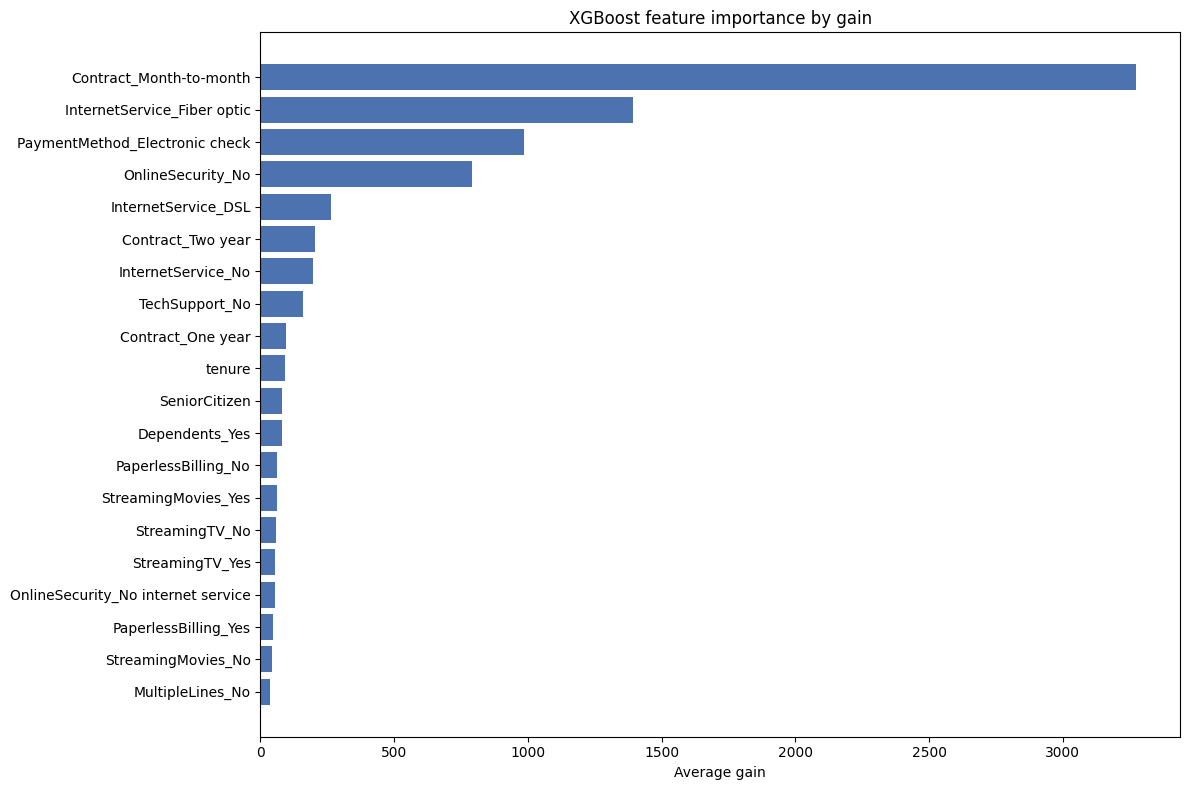

In [109]:
feature_names = preprocessor.get_feature_names_out()

booster = xgboost.get_booster()
scores = booster.get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature": [feature_names[int(name[1:])] for name in scores.keys()],
    "gain": list(scores.values())
}).sort_values("gain", ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(importance_df["feature"][::-1], importance_df["gain"][::-1], color="#4C72B0")
plt.title("XGBoost feature importance by gain")
plt.xlabel("Average gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

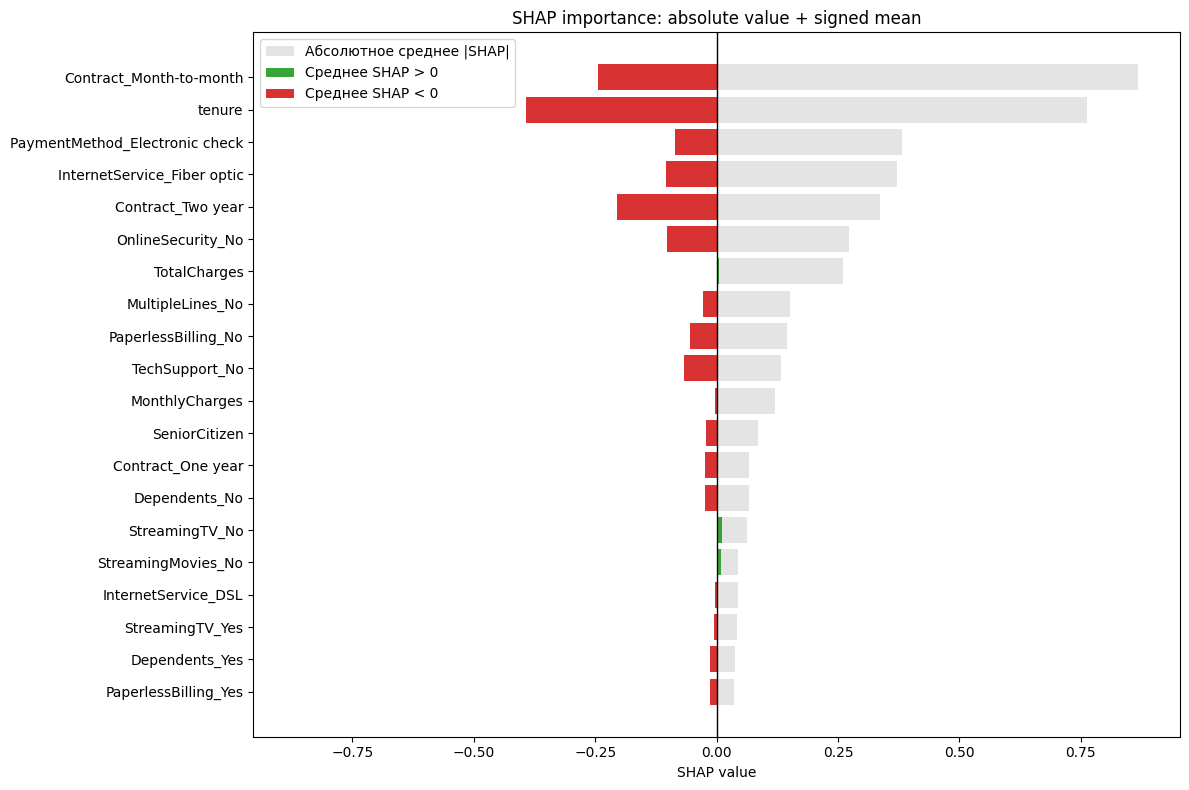

In [ ]:
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X, columns=feature_names)

explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_df)

mean_shap = shap_values.mean(axis=0)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_shap": mean_shap,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).head(20)

plot_df = shap_importance_df.copy().sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"],
    color="#D9D9D9",
    alpha=0.7,
    label="Абсолютное среднее |SHAP|"
)

signed_colors = np.where(plot_df["mean_shap"] >= 0, "#2CA02C", "#D62728")
ax.barh(
    plot_df["feature"],
    plot_df["mean_shap"],
    color=signed_colors,
    alpha=0.95
)

ax.axvline(0, color="black", linewidth=1)
ax.set_title("SHAP importance: absolute value + signed mean")
ax.set_xlabel("SHAP value")
ax.set_ylabel("")

legend_handles = [
    Patch(facecolor="#D9D9D9", alpha=0.7, label="Абсолютное среднее |SHAP|"),
    Patch(facecolor="#2CA02C", alpha=0.95, label="Среднее SHAP > 0"),
    Patch(facecolor="#D62728", alpha=0.95, label="Среднее SHAP < 0"),
]
ax.legend(handles=legend_handles)

xmax = plot_df["mean_abs_shap"].max()
ax.set_xlim(-xmax * 1.1, xmax * 1.1)

plt.tight_layout()
plt.show()

##### Ключевые признаки и влияние (по SHAP и XGBoost)

<small>

**Contract_Month-to-month** - самый важный признак по абсолютному значению SHAP. Средний вклад отрицательный, что означает снижение предсказания класса 1 в среднем по выборке.

**tenure** — один из наиболее влиятельных факторов. Средний SHAP отрицательный, что соответствует снижению вероятности ухода при увеличении стажа клиента.

**Contract_Two year** — стабильно даёт отрицательный вклад, что соответствует снижению вероятности ухода для клиентов с долгосрочным контрактом.

**OnlineSecurity_No** — имеет большой отрицательный средний вклад
</small>


### Stacking с Logistic Regression как мета-моделью

In [80]:
def get_oof_predictions(model, X, y, X_test, n_splits=5, random_state=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_train = np.zeros(len(X))
    oof_test = np.zeros(len(X_test))
    test_fold_preds = []

    for train_idx, valid_idx in tqdm(skf.split(X, y), total=n_splits):
        X_train_fold, X_valid_fold = X[train_idx], X[valid_idx]
        y_train_fold = y[train_idx]

        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)

        oof_train[valid_idx] = fold_model.predict_proba(X_valid_fold)[:, 1]
        test_fold_preds.append(fold_model.predict_proba(X_test)[:, 1])

    oof_test = np.mean(test_fold_preds, axis=0)
    return oof_train.reshape(-1, 1), oof_test.reshape(-1, 1)

lgbm_oof_train, lgbm_oof_test = get_oof_predictions(lightgbm, X_train, y_train, X_test, n_splits=3, random_state=RANDOM_STATE)
cat_oof_train, cat_oof_test = get_oof_predictions(catboost, X_train, y_train, X_test, n_splits=3, random_state=RANDOM_STATE)
random_forest_oof_train, random_forest_oof_test = get_oof_predictions(random_forest, X_train, y_train, X_test, n_splits=3, random_state=RANDOM_STATE)
xgboost_oof_train, xgboost_oof_test = get_oof_predictions(xgboost, X_train, y_train, X_test, n_splits=3, random_state=RANDOM_STATE)

X_stack_train = np.hstack([lgbm_oof_train, cat_oof_train, random_forest_oof_train, xgboost_oof_train])
X_stack_test = np.hstack([lgbm_oof_test, cat_oof_test, random_forest_oof_test, xgboost_oof_test])

100%|██████████| 3/3 [00:08<00:00,  2.96s/it]


In [81]:
def lr_objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 1e2, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "saga",
        "max_iter": 4000,
        "random_state": RANDOM_STATE,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in skf.split(X_stack_train, y_train):
        X_tr, X_val = X_stack_train[tr_idx], X_stack_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        clf = LogisticRegression(**params)
        clf.fit(X_tr, y_tr)
        prob = clf.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, prob))
    return float(np.mean(scores))

if PRE_TRAINDED_MODE:
    best_params = joblib.load("./saved models/stack_logreg.joblib").get_params()
else:
    n_trials = 20
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda t: lr_objective(t), n_trials=n_trials)

    best_params = study.best_params.copy()
    best_params.update({"solver": "saga", "max_iter": 4000, "random_state": RANDOM_STATE})


print(f"Best trial: {study.best_trial.number}")

row, stack_logreg = hub.fit_predict(
    LogisticRegression,
    X_stack_train,
    y_train,
    model_name="StackingLogReg",
    params=best_params,
    n_splits=5,
    return_model=True,
)
joblib.dump(stack_logreg, "saved models/stack_logreg.joblib")
hub.leaderboard(only_best=True)


Best trial: 12


,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,XGBClassifier (loaded),0.0000,0.0636,0.8611,0.7120,0.6440,0.6763,0.9166,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7718500461081756, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.0018768875329013197, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.06380730584961225, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': 8, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 454, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 3.3149587052001917e-07, 'reg_lambda': 0.01347090624623844, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9229828604603908, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': 0}"
1,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
2,LightGBM (loaded),0.0000,0.3381,0.8608,0.7098,0.6460,0.6764,0.9166,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}"
3,StackingLogReg,0.5730,0.0005,0.8428,0.6138,0.8142,0.7000,0.9158,"{'C': 0.0010385873636109106, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0003233116543683093, 'max_iter': 4000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}"
4,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
5,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


In [82]:
X_stack_test_extended = np.hstack([X_stack_test, X_test])
X_stack_train_extended = np.hstack([X_stack_train, X_train])
def lr_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),

        "objective": "binary",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for tr_idx, val_idx in skf.split(X_stack_train_extended, y_train):
        X_tr, X_val = X_stack_train_extended[tr_idx], X_stack_train_extended[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        clf = LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        prob = clf.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, prob))

    return float(np.mean(scores))

if PRE_TRAINDED_MODE:
    best_params = joblib.load("./saved models/stack_lightgbm.joblib").get_params()
else:
    n_trials = 20
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda t: lr_objective(t), n_trials=n_trials)

    best_params = study.best_params.copy()
    best_params.update({"random_state": RANDOM_STATE})


print(f"Best trial: {study.best_trial.number}")

row, stack_lightgbm = hub.fit_predict(
    LGBMClassifier,
    X_stack_train_extended,
    y_train,
    model_name="StackingLightGBM",
    params=best_params,
    n_splits=5,
    return_model=True,
)
joblib.dump(stack_lightgbm, "saved models/stack_lightgbm.joblib")
hub.leaderboard(only_best=True)


Best trial: 13


,model,fit_time_sec,predict_time_sec,accuracy,precision,recall,f1,roc_auc,params
0,XGBClassifier (loaded),0.0000,0.0636,0.8611,0.7120,0.6440,0.6763,0.9166,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7718500461081756, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.0018768875329013197, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.06380730584961225, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': 8, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 454, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 3.3149587052001917e-07, 'reg_lambda': 0.01347090624623844, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9229828604603908, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': 0}"
1,CatBoostClassifier (loaded),0.0000,0.1280,0.8613,0.7134,0.6422,0.6760,0.9166,"{'depth': 6, 'random_seed': 42, 'od_wait': 50, 'l2_leaf_reg': 0.5, 'iterations': 5000, 'verbose': 0, 'loss_function': 'Logloss'}"
2,LightGBM (loaded),0.0000,0.3381,0.8608,0.7098,0.6460,0.6764,0.9166,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}"
3,StackingLightGBM,0.6571,0.0461,0.8610,0.7320,0.6041,0.6619,0.9160,"{'n_estimators': 106, 'learning_rate': 0.02147803104709081, 'num_leaves': 35, 'max_depth': 4, 'min_child_samples': 11, 'subsample': 0.7399420544484542, 'colsample_bytree': 0.8754914187802076, 'reg_alpha': 0.002751663958629693, 'reg_lambda': 0.001608504988229927, 'random_state': 42}"
4,StackingLogReg,0.5730,0.0005,0.8428,0.6138,0.8142,0.7000,0.9158,"{'C': 0.0010385873636109106, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0003233116543683093, 'max_iter': 4000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}"
5,RandomForestClassifier (loaded),0.0000,0.2165,0.8560,0.6986,0.6342,0.6648,0.9118,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}"
6,LogisticRegression,0.5894,0.0024,0.8545,0.6848,0.6557,0.6699,0.9078,None


In [87]:
test_proba = xgboost.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test["id"],
    "Churn": test_proba
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Churn
0,594194,0.077026
1,594195,0.000733
2,594196,0.105655
3,594197,0.004400
4,594198,0.546077
